# EmoExpress: GoEmotions Data Exploration and Preprocessing

## Objective

This notebook loads and explores the GoEmotions dataset, analyzes its
multi-label emotion categories, checks data quality and class imbalance,
and prepares the data for traditional machine-learning, deep-learning,
and transformer-based emotion classifiers.

Import libraries

In [2]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

Configure project paths

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"

for directory in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)

Project root: d:\FullStack_Academic\Final Capstone\EmoExpress
Raw data directory: d:\FullStack_Academic\Final Capstone\EmoExpress\data\raw
Processed data directory: d:\FullStack_Academic\Final Capstone\EmoExpress\data\processed


Load GoEmotions Data

In [4]:
DATASET_NAME = "google-research-datasets/go_emotions"
DATASET_CONFIG = "simplified"

goemotions = load_dataset(DATASET_NAME, DATASET_CONFIG)

goemotions

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Inspect the dataset

In [5]:
# inspect the features of train set
print(goemotions["train"].column_names)
print(goemotions["train"].features)

['text', 'labels', 'id']
{'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}


In [6]:
# print the firt 3 sample in train set
for index in range(3):
    print(f"Example {index + 1}")
    print("Text:", goemotions["train"][index]["text"])
    print("Label IDs:", goemotions["train"][index]["labels"])
    print("ID:", goemotions["train"][index]["id"])
    print("-" * 80)

Example 1
Text: My favourite food is anything I didn't have to cook myself.
Label IDs: [27]
ID: eebbqej
--------------------------------------------------------------------------------
Example 2
Text: Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
Label IDs: [27]
ID: ed00q6i
--------------------------------------------------------------------------------
Example 3
Text: WHY THE FUCK IS BAYLESS ISOING
Label IDs: [2]
ID: eezlygj
--------------------------------------------------------------------------------


**Observation**
- There are 43,410 entries for train set, 5,426 for validation set and 5,427 for test set from GoEmotions dataset.
- The dataset contains 3 columns which are text, labels and id. 
- The 'labels' column presents in number, which we need to convert it to text to recognize which emotion it is. 

Extract emotion label names

In [7]:
label_feature = goemotions["train"].features["labels"].feature
emotion_names = label_feature.names

print("Number of emotion labels:", len(emotion_names))
print(emotion_names)

Number of emotion labels: 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


Decode label IDs into emotion names

In [8]:
def decode_emotions(label_ids: list[int]) -> list[str]:
    """
    Convert GoEmotions integer label IDs into emotion names.
    """
    return [emotion_names[label_id] for label_id in label_ids]

In [9]:
for index in range(3):
    example = goemotions["train"][index]

    print("Text:", example["text"])
    print("Emotions:", decode_emotions(example["labels"]))
    print("-" * 80)

Text: My favourite food is anything I didn't have to cook myself.
Emotions: ['neutral']
--------------------------------------------------------------------------------
Text: Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
Emotions: ['neutral']
--------------------------------------------------------------------------------
Text: WHY THE FUCK IS BAYLESS ISOING
Emotions: ['anger']
--------------------------------------------------------------------------------


**Observation**
- There are 28 labeled emotions.
- After decoding the labels, we can decide which kind of emtion from the text.

Convert splits to Pandas DataFrames

In [ ]:
train_df = goemotions["train"].to_pandas()
validation_df = goemotions["validation"].to_pandas()
test_df = goemotions["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Train shape: (43410, 3)
Validation shape: (5426, 3)
Test shape: (5427, 3)


In [ ]:
# Add readable emotion columns using decode_emotions define function:
for dataframe in [train_df, validation_df, test_df]:
    dataframe["emotion_names"] = dataframe["labels"].apply(
        lambda label_ids: decode_emotions(list(label_ids))
    )

In [13]:
train_df[["text", "labels", "emotion_names"]].head(3)

,text,labels,emotion_names
0,My favourite food is anything I didn't have to...,[27],[neutral]
1,"Now if he does off himself, everyone will thin...",[27],[neutral]
2,WHY THE FUCK IS BAYLESS ISOING,[2],[anger]


Check missing values

In [ ]:
print("Training missing values:")
print(train_df.isnull().sum())

print("\nValidation missing values:")
print(validation_df.isnull().sum())

print("\nTest missing values:")
print(test_df.isnull().sum())

Training missing values:
text             0
labels           0
id               0
emotion_names    0
dtype: int64

Validation missing values:
text             0
labels           0
id               0
emotion_names    0
dtype: int64

Test missing values:
text             0
labels           0
id               0
emotion_names    0
dtype: int64


Check empty text

In [ ]:
def count_empty_text(dataframe: pd.DataFrame) -> int:
    return dataframe["text"].fillna("").str.strip().eq("").sum()

print("Empty train text:", count_empty_text(train_df))
print("Empty validation text:", count_empty_text(validation_df))
print("Empty test text:", count_empty_text(test_df))

Empty train text: 0
Empty validation text: 0
Empty test text: 0


Check duplicate text

In [17]:
print("Duplicate training texts:", train_df["text"].duplicated().sum())
print(
    "Duplicate validation texts:",
    validation_df["text"].duplicated().sum()
)
print("Duplicate test texts:", test_df["text"].duplicated().sum())

Duplicate training texts: 183
Duplicate validation texts: 3
Duplicate test texts: 6


Check overlap between splits:

In [18]:
train_texts = set(train_df["text"])
validation_texts = set(validation_df["text"])
test_texts = set(test_df["text"])

print(
    "Train-validation overlap:",
    len(train_texts.intersection(validation_texts))
)

print(
    "Train-test overlap:",
    len(train_texts.intersection(test_texts))
)

print(
    "Validation-test overlap:",
    len(validation_texts.intersection(test_texts))
)

Train-validation overlap: 41
Train-test overlap: 32
Validation-test overlap: 10


**Observation**
- There is no missing value and no empty text in splits. 
- There are 183 duplicated texts in train set, 3 duplicated text in validation set and 6 duplicated texts in test set
- There are 41 texts overlap between train and validation set, 32 texts overlap between train and test set, and 10 texts overlap between validation and test set.

**Analyze length of labels each split has**

In [31]:
for dataframe in [train_df, validation_df, test_df]:
    dataframe["label_count"] = dataframe["labels"].apply(len)

# Display distribution:
label_count_train_df = (train_df["label_count"].value_counts().sort_index())
label_count_validation_df = (validation_df["label_count"].value_counts().sort_index())
label_count_test_df = (test_df["label_count"].value_counts().sort_index())


label_count
1    36308
2     6541
3      532
4       28
5        1
Name: count, dtype: int64


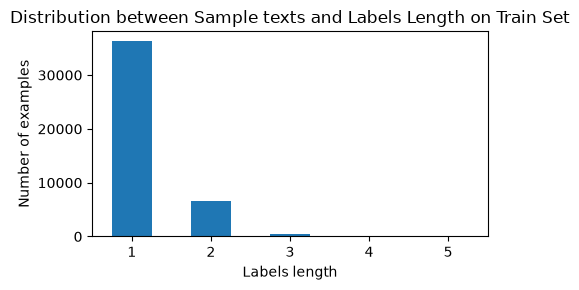

Saved figure: d:\FullStack_Academic\Final Capstone\EmoExpress\outputs\figures\labels_per_example_train.png


In [44]:
# print counting number of labels in train set
print(label_count_train_df)
# plot
plt.figure(figsize=(5, 3))
label_count_train_df.plot(kind="bar")
plt.title("Distribution between Sample texts and Labels Length on Train Set")
plt.xlabel("Labels length")
plt.ylabel("Number of examples")
plt.xticks(rotation=0)
plt.tight_layout()

figure_path = FIGURE_DIR / "labels_per_example_train.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure:", figure_path)


label_count
1    4548
2     809
3      62
4       7
Name: count, dtype: int64


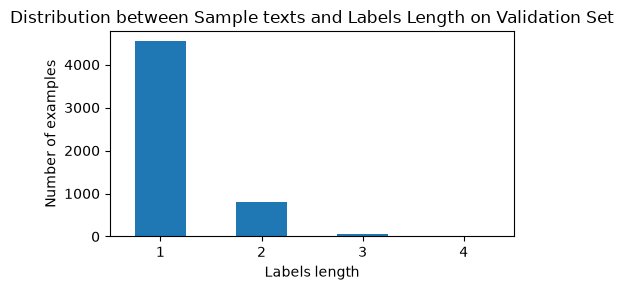

Saved figure: d:\FullStack_Academic\Final Capstone\EmoExpress\outputs\figures\labels_per_example_validation.png


In [46]:
# print counting number of labels in validation set
print(label_count_validation_df)
# plot
plt.figure(figsize=(5, 3))
label_count_validation_df.plot(kind="bar")
plt.title("Distribution between Sample texts and Labels Length on Validation Set")
plt.xlabel("Labels length")
plt.ylabel("Number of examples")
plt.xticks(rotation=0)
plt.tight_layout()

figure_path = FIGURE_DIR / "labels_per_example_validation.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure:", figure_path)

label_count
1    4590
2     774
3      61
4       2
Name: count, dtype: int64


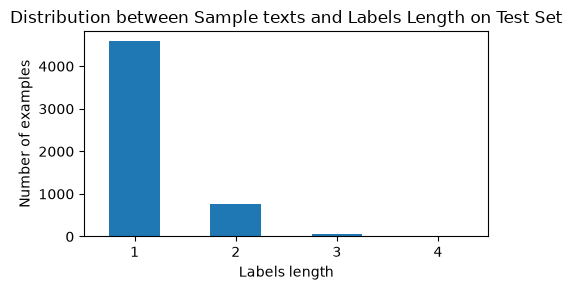

Saved figure: d:\FullStack_Academic\Final Capstone\EmoExpress\outputs\figures\labels_per_example_test.png


In [47]:
# print counting number of labels in test set
print(label_count_test_df)
# plot
plt.figure(figsize=(5, 3))
label_count_test_df.plot(kind="bar")
plt.title("Distribution between Sample texts and Labels Length on Test Set")
plt.xlabel("Labels length")
plt.ylabel("Number of examples")
plt.xticks(rotation=0)
plt.tight_layout()

figure_path = FIGURE_DIR / "labels_per_example_test.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure:", figure_path)

**Observation**
- Most of labesl in plits have the length of one while length of two is barely and length of three or four or five is rarely. 

Analyze emotion frequency

In [ ]:
def calculate_emotion_counts(dataframe: pd.DataFrame) -> pd.DataFrame:
    all_emotions = [emotion for emotions in dataframe["emotion_names"] for emotion in emotions]

    counts = Counter(all_emotions)

    emotion_counts_df = pd.DataFrame(
        {
            "emotion": list(counts.keys()),
            "count": list(counts.values()),
        }
    )

    return emotion_counts_df.sort_values("count", ascending=False).reset_index(drop=True)

In [50]:
train_emotion_counts = calculate_emotion_counts(train_df)
train_emotion_counts

,emotion,count
0,neutral,14219
1,admiration,4130
2,approval,2939
3,gratitude,2662
4,annoyance,2470
5,amusement,2328
6,curiosity,2191
7,love,2086
8,disapproval,2022
9,optimism,1581


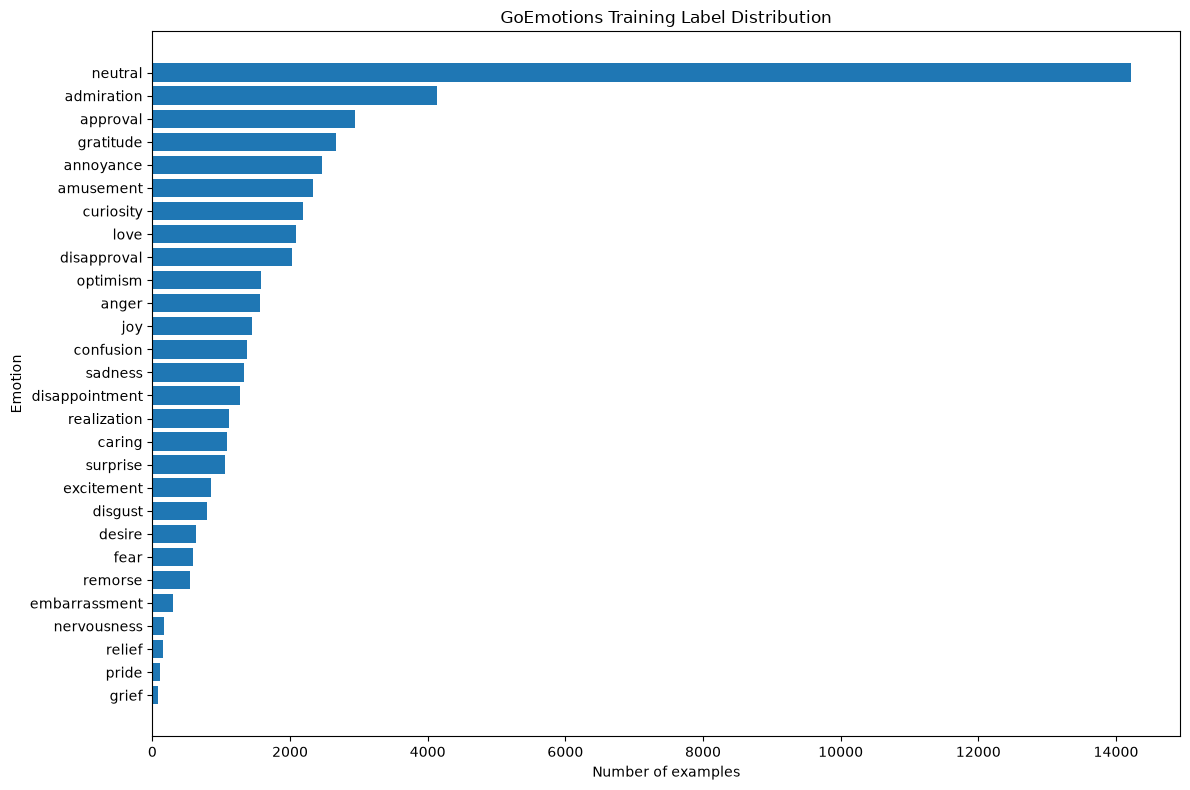

Saved figure: d:\FullStack_Academic\Final Capstone\EmoExpress\outputs\figures\training_emotion_label_distribution.png


In [ ]:
plt.figure(figsize=(12, 8))

plt.barh(train_emotion_counts["emotion"], train_emotion_counts["count"])

plt.title("GoEmotions Training Label Distribution")
plt.xlabel("Number of examples")
plt.ylabel("Emotion")
plt.gca().invert_yaxis()
plt.tight_layout()

figure_path = FIGURE_DIR / "training_emotion_label_distribution.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure:", figure_path)

In [55]:
# Calculate emotion percentages
total_training_labels = train_emotion_counts["count"].sum()

train_emotion_counts["percentage"] = (
    train_emotion_counts["count"]
    / total_training_labels
    * 100
)


In [ ]:
# Display the most frequent emotions:
print("Most frequent emotions:")
display(train_emotion_counts.head(5))


Most frequent emotions:


,emotion,count,percentage
0,neutral,14219,27.824198
1,admiration,4130,8.081717
2,approval,2939,5.751130
3,gratitude,2662,5.209088
4,annoyance,2470,4.833376


In [57]:
# Display the least frequent emotions:
print("Least frequent emotions:")
display(train_emotion_counts.tail(5))

Least frequent emotions:


,emotion,count,percentage
23,embarrassment,303,0.592920
24,nervousness,164,0.320920
25,relief,153,0.299395
26,pride,111,0.217208
27,grief,77,0.150676


Analyze text length

In [58]:
train_df["character_count"] = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

train_df[["character_count", "word_count"]].describe()

,character_count,word_count
count,43410.000000,43410.000000
mean,68.400875,12.840175
std,36.721898,6.701597
min,2.000000,1.000000
25%,38.000000,7.000000
50%,65.000000,12.000000
75%,96.000000,18.000000
max,703.000000,33.000000


# Preprocessing

**Create traditional ML preprocessing**

In [60]:
import re

In [61]:
def clean_text_for_ml(text: str) -> str:
    """
    Clean text for TF-IDF-based traditional ML models.

    This function:
    - converts text to lowercase;
    - removes URLs;
    - removes Reddit user references;
    - removes unnecessary special characters;
    - normalizes whitespace.

    Negation words are preserved because they can affect emotion.
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    text = re.sub(
        r"/?u/\w+",
        " ",
        text
    )

    text = re.sub(
        r"[^a-z0-9\s'!?.,-]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [63]:
# Apply preprocessing
for dataframe in [train_df, validation_df, test_df]:
    dataframe["clean_text_ml"] = dataframe["text"].apply(
        clean_text_for_ml
    )

In [64]:
# print the sample
train_df[["text","clean_text_ml","emotion_names"]].head(3)

,text,clean_text_ml,emotion_names
0,My favourite food is anything I didn't have to...,my favourite food is anything i didn't have to...,[neutral]
1,"Now if he does off himself, everyone will thin...","now if he does off himself, everyone will thin...",[neutral]
2,WHY THE FUCK IS BAYLESS ISOING,why the fuck is bayless isoing,[anger]


**Build multi-hot label vectors**

In [ ]:
NUM_LABELS = len(emotion_names)

def create_multi_hot_vector(label_ids: list[int], number_of_labels: int = NUM_LABELS) -> list[int]:
    """
    Convert emotion label IDs into a multi-hot binary vector.
    """
    vector = np.zeros(
        number_of_labels,
        dtype=np.int8
    )

    vector[list(label_ids)] = 1

    return vector.tolist()

In [ ]:
# appply
for dataframe in [train_df, validation_df, test_df]:
    dataframe["label_vector"] = dataframe["labels"].apply(
        lambda label_ids: create_multi_hot_vector(
            list(label_ids)
        )
    )

In [69]:
example = train_df.iloc[0]

print("Text:", example["text"])
print("Emotion names:", example["emotion_names"])
print("Label vector:", example["label_vector"])
print("Vector length:", len(example["label_vector"]))

Text: My favourite food is anything I didn't have to cook myself.
Emotion names: ['neutral']
Label vector: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Vector length: 28


**Save the processed data**

In [70]:
import json

Create a saving function:

In [84]:
def prepare_dataframe_for_csv(dataframe: pd.DataFrame) -> pd.DataFrame:
    output_dataframe = dataframe.copy()

    output_dataframe["labels"] = output_dataframe["labels"].apply(
        lambda values: json.dumps([int(v) for v in values])
    )

    output_dataframe["emotion_names"] = output_dataframe["emotion_names"].apply(
        lambda values: json.dumps(list(values))
    )

    output_dataframe["label_vector"] = output_dataframe["label_vector"].apply(
        lambda values: json.dumps([int(v) for v in values])
    )

    return output_dataframe

Save each split:

In [85]:
train_output = prepare_dataframe_for_csv(train_df)
validation_output = prepare_dataframe_for_csv(validation_df)
test_output = prepare_dataframe_for_csv(test_df)

train_path = PROCESSED_DATA_DIR / "goemotions_train.csv"
validation_path = PROCESSED_DATA_DIR / "goemotions_validation.csv"
test_path = PROCESSED_DATA_DIR / "goemotions_test.csv"

train_output.to_csv(train_path, index=False)
validation_output.to_csv(validation_path, index=False)
test_output.to_csv(test_path, index=False)

print("Saved:", train_path)
print("Saved:", validation_path)
print("Saved:", test_path)

Saved: d:\FullStack_Academic\Final Capstone\EmoExpress\data\processed\goemotions_train.csv
Saved: d:\FullStack_Academic\Final Capstone\EmoExpress\data\processed\goemotions_validation.csv
Saved: d:\FullStack_Academic\Final Capstone\EmoExpress\data\processed\goemotions_test.csv


Save label mapping

In [86]:
label_mapping = {
    str(index): emotion
    for index, emotion in enumerate(emotion_names)
}

label_mapping_path = (
    PROCESSED_DATA_DIR / "emotion_label_mapping.json"
)

with open(
    label_mapping_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        label_mapping,
        file,
        indent=4
    )

print("Saved:", label_mapping_path)

Saved: d:\FullStack_Academic\Final Capstone\EmoExpress\data\processed\emotion_label_mapping.json


In [ ]:
# Verify saved files
saved_files = list(PROCESSED_DATA_DIR.iterdir())

for file_path in saved_files:
    print(file_path.name)

goemotions_train.csv
goemotions_validation.csv
goemotions_test.csv
emotion_label_mapping.json


# Conclusion

The GoEmotions dataset was successfully loaded with predefined training,validation, and test splits.

The dataset contains 28 labels: 27 emotion categories and one neutral category. Because individual comments may contain more than one emotion, the task is treated as multi-label classification.

The exploration showed that the emotion labels are imbalanced. This means that evaluation should include both Micro F1 and Macro F1 rather than accuracy alone.

Two text representations were retained:

1. Original text for transformer models such as DistilBERT and RoBERTa.
2. Cleaned text for TF-IDF-based Logistic Regression and Linear SVM.

The labels were also converted into 28-dimensional multi-hot vectors. The processed splits and label mapping were saved for use in later notebooks.